In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('netflix_titles.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
#Columns Having null values
df[['director','cast','country','date_added','rating','duration']]

,director,cast,country,date_added,rating,duration
0,Kirsten Johnson,NaN,United States,"September 25, 2021",PG-13,90 min
1,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",TV-MA,2 Seasons
2,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",TV-MA,1 Season
3,NaN,NaN,NaN,"September 24, 2021",TV-MA,1 Season
4,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",TV-MA,2 Seasons
...,...,...,...,...,...,...
8802,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",R,158 min
8803,NaN,NaN,NaN,"July 1, 2019",TV-Y7,2 Seasons
8804,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",R,88 min
8805,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",PG,88 min


In [9]:
# df['director'] = df['director'].fillna('Unknown')

In [10]:
null_columns = ['director','cast','country','rating']
for i in null_columns:
    df[i] = df[i].fillna('Unknown')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [12]:
df.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [13]:
df[df['duration'].isna()]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [14]:
df['duration'].isna().sum()

3

In [15]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR',
       'Unknown', 'TV-Y7-FV', 'UR'], dtype=object)

In [16]:
df[df['rating'].str.contains('min', na=False)]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [17]:
df[df['rating'].str.contains('min|Season')]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [18]:
df.loc[df['duration'].isna(),'duration'] = df.loc[df['duration'].isna(),'duration'].fillna(df['rating'])

In [19]:
df.loc[[5541,5794,5813],['title','director','cast']]

,title,director,cast
5541,Louis C.K. 2017,Louis C.K.,Louis C.K.
5794,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.
5813,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.


In [20]:
df.loc[df['rating'].str.contains('min'),'rating'] = 'no data'

In [21]:
df.loc[df['rating'] == 'no data']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,no data,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,no data,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,no data,66 min,Movies,The comic puts his trademark hilarious/thought...


In [22]:
#onlt date added has null values now

In [23]:
df.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [24]:
df['date_added']

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8802     November 20, 2019
8803          July 1, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, Length: 8807, dtype: object

In [25]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [26]:
df['date_added'].nunique()

1767

In [27]:
df['date_added'] = df['date_added'].str.strip()

In [28]:
df1 = df.copy()

In [29]:
# df['date_added'] = df['date_added'].fillna('no data')
#df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')


In [30]:
df.loc[df['date_added'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,Unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,Unknown,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,Unknown,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,Unknown,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,Unknown,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,Unknown,Igor Dmitriev,Unknown,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,Unknown,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,Unknown,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,Unknown,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,Unknown,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [31]:
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [32]:
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [34]:
df.columns = df.columns.str.title()

In [35]:
df.columns

Index(['Show_Id', 'Type', 'Title', 'Director', 'Cast', 'Country', 'Date_Added',
       'Release_Year', 'Rating', 'Duration', 'Listed_In', 'Description'],
      dtype='object')

In [36]:
df['Year_Added'] = df['Date_Added'].dt.year

In [37]:
df['No_of_Cast'] = df['Cast'].str.split(',').str.len()

In [38]:
df.columns

Index(['Show_Id', 'Type', 'Title', 'Director', 'Cast', 'Country', 'Date_Added',
       'Release_Year', 'Rating', 'Duration', 'Listed_In', 'Description',
       'Year_Added', 'No_of_Cast'],
      dtype='object')

# Visualization

### Movies vs TV Shows


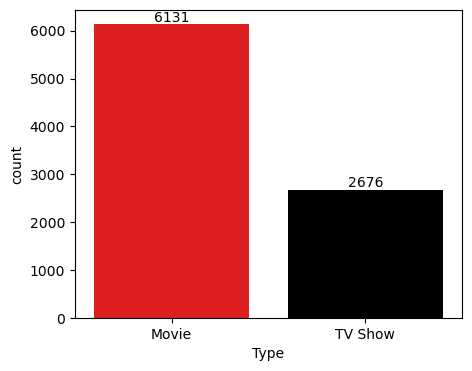

In [39]:
plt.figure(figsize=(5,4))
f = sns.countplot(data=df,x='Type',palette=['Red','Black'])
for i in f.containers:
    f.bar_label(i)
plt.show()

Movies clearly dominate the catalog with 6131 titles, showing Netflix has released more films than TV shows, which stand at 2676. Overall, the platform leans heavily toward movie content.


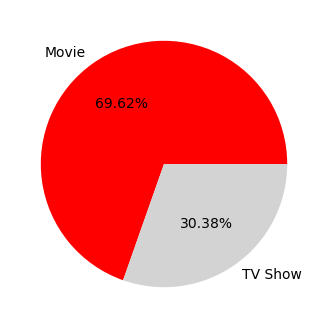

In [40]:
f=df['Type'].value_counts()
plt.figure(figsize=(5,4))
plt.pie(x=f.values,labels=f.index,autopct='%.2f%%',colors=['red','lightgrey'])
plt.show()

The pie chart shows that movies make up nearly 70% of the total content, indicating they are the dominant format on the platform. TV shows only has about 30%, highlighting a smaller share.


### Top 10 Countries

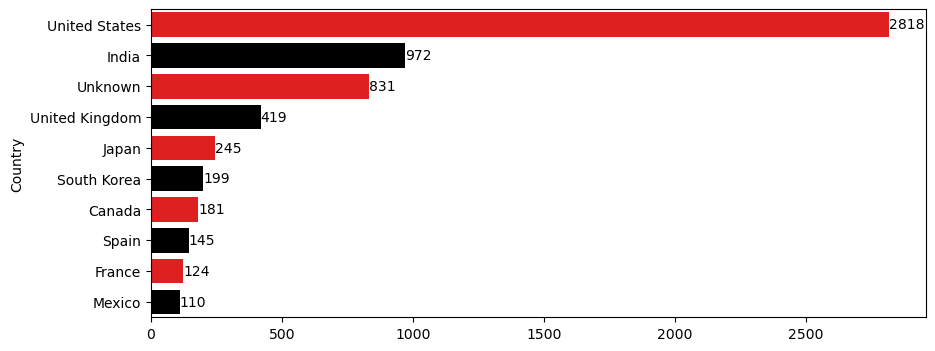

In [41]:
plt.figure(figsize=(10,4))
f = df['Country'].value_counts().head(10)
s = sns.barplot(x=f.values,y=f.index,palette=['Red','Black'])
for i in s.containers:
    s.bar_label(i)
plt.show()


The United States dominates Netflix content production with a significantly higher number of titles than any other country.


# Most Common Content Ratings on Netflix

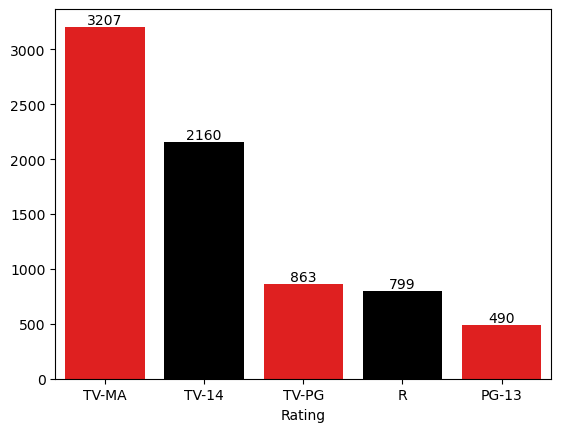

In [43]:
f = df['Rating'].value_counts().head(5)
s= sns.barplot(x=f.index,y=f.values,palette=['Red','Black'])
for i in s.containers:
    s.bar_label(i)
plt.show()

TV-MA is the dominant rating on Netflix, indicating a strong presence of mature content on the platform.

# Release Year Trends 

c:\Users\sreer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sreer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


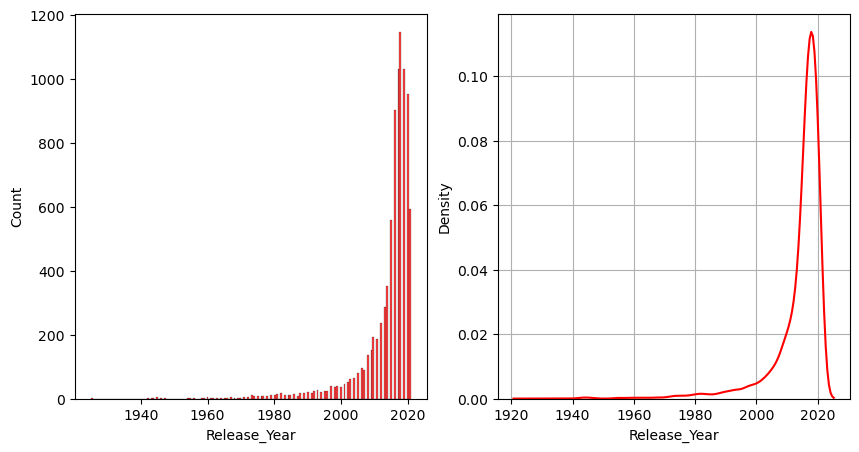

In [45]:
fig,axes = plt.subplots(ncols=2,figsize=(10,5))
sns.histplot(data=df,x='Release_Year',color='Red',ax=axes[0])
sns.kdeplot(data=df,x='Release_Year',color='Red',ax=axes[1])
plt.grid()
plt.show()

Most content were released after 2000, with a sharp spike in releases from 2010 onward.

# Distribution of Content Added to Netflix by Year

c:\Users\sreer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sreer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


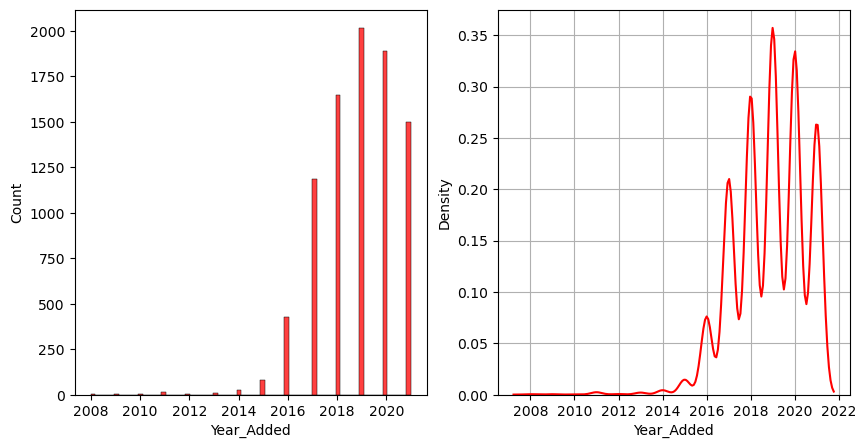

In [ ]:
fig,axes = plt.subplots(ncols=2,figsize=(10,5))
sns.histplot(data=df,x='Year_Added',color='Red',ax=axes[0])
sns.kdeplot(data=df,x='Year_Added',color='Red',ax=axes[1])
plt.grid()
plt.show()

The number of content added to Netflix rose sharply after 2015, peaking between 2018 and 2020, which shows Netflix’s rapid growth during this period.


# Release Year vs Year Added

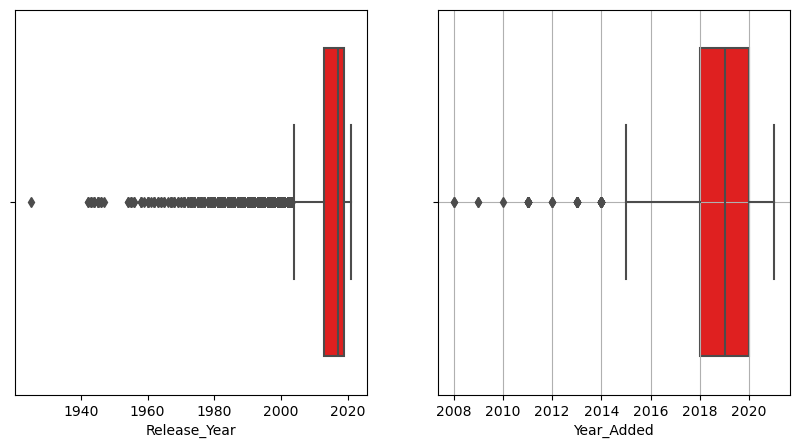

In [ ]:
fig,axes = plt.subplots(ncols=2,figsize=(10,5))
sns.boxplot(data=df,x='Release_Year',color='Red',ax=axes[0])
sns.boxplot(data=df,x='Year_Added',color='Red',ax=axes[1])
plt.grid()
plt.show()

Most titles were released and added in recent years, showing a strong focus on newer content. A few very old titles appear as outliers.

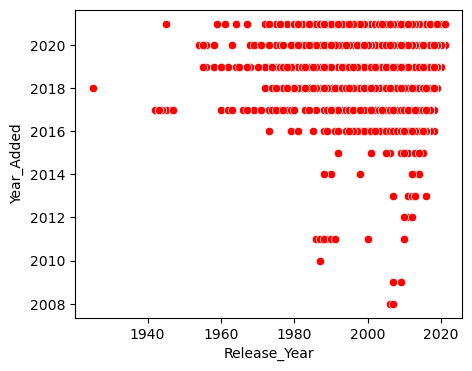

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=df,x='Release_Year',y='Year_Added',color='Red')
plt.show()

Most titles released after 2000 were added to Netflix quickly, especially between 2016 and 2020. Older titles appear less often and were added much later.


# CONCLUSION

Netflix’s catalog is mostly made up of movies and TV shows.
Most content comes from the United States and a few other major countries.
Popular genres include dramas, documentaries, and stand-up comedy.
Most titles were released after 2000 and added to Netflix mainly between 2016 and 2020.
Overall, Netflix focuses heavily on modern content and adds a large number of titles each year.
